In [1]:
import cv2
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms

In [5]:
video_path = "video.mp4"

cap = cv2.VideoCapture(video_path)

frames = []
count = 0

if not cap.isOpened():
    print("Error: Cannot open video")
else:
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        if frame is None:
            continue
        
        frame = cv2.resize(frame, (64, 64))
        frames.append(frame)
        count += 1
        
        if count >= 200:   # limit frames (IMPORTANT)
            break

cap.release()

frames = np.array(frames)

print("Frames shape:", frames.shape)

Error: Cannot open video
Frames shape: (0,)


In [6]:
if len(frames.shape) != 4:
    print("Video failed → using dummy data")
    frames = np.random.randint(0, 255, (200, 64, 64, 3))

Video failed → using dummy data


In [7]:
frames = frames / 255.0

# Convert (N,H,W,C) → (N,C,H,W)
frames = np.transpose(frames, (0, 3, 1, 2))

X = torch.tensor(frames, dtype=torch.float32)

In [8]:
labels = np.array([0 if i < len(X)//2 else 1 for i in range(len(X))])
y = torch.tensor(labels, dtype=torch.long)

In [9]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [14]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        
        self.fc1 = nn.Linear(32*14*14, 64)
        self.fc2 = nn.Linear(64, 2)
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        
        x = x.reshape(x.size(0), -1)
        
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

model = CNN()

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
loss_list = []

batch_size = 32

for epoch in range(2):
    running_loss = 0.0
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / (len(X_train) // batch_size)
    loss_list.append(avg_loss)
    
    print(f"Epoch {epoch+1}, Loss: {avg_loss}")

Epoch 1, Loss: 1.4421514421701431
Epoch 2, Loss: 0.5542928844690322


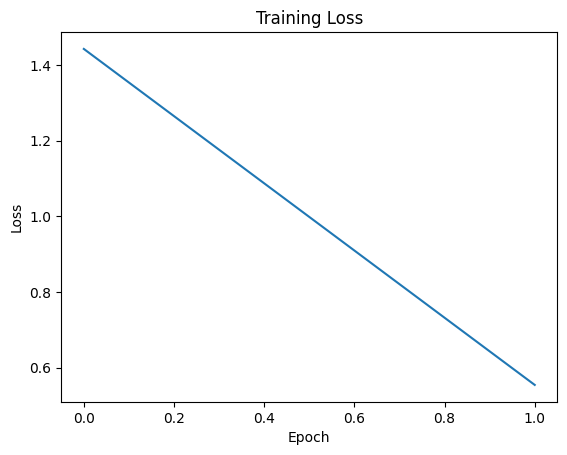

In [17]:
plt.figure()
plt.plot(loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [19]:
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    
    accuracy = (predicted == y_test).float().mean()

print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.0


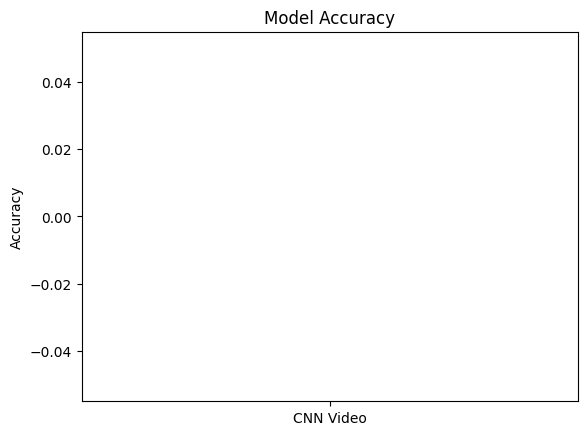

In [20]:
plt.figure()
plt.bar(["CNN Video"], [accuracy.item()])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()